# Spot smoothness sweep

Companion to `spots_configurations.ipynb`: every panel renders the **same** spot (same centre, radius, and temperature contrast) but varies the `smoothness` argument of `add_spots`. Smoothness controls how the edge of the spot is feathered into the photosphere — `0.0` is a hard step at the angular radius, larger values progressively smooth the edge until at `~1.0` the profile is essentially a Gaussian-like bump. Same camera, colormap and rasterisation as the spots gallery so the two figures live side-by-side in the paper.

In [1]:
import sys
sys.path.append('../../../src')

from spice.models import IcosphereModel
from spice.models.spots import add_spots
from spice.models.utils import lat_to_theta, lon_to_phi

import jax.numpy as jnp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import art3d

%matplotlib inline

## Base mesh

Single-parameter mesh (effective temperature only) so the colorbar maps directly to spot temperature contrast.

In [2]:
T_BASE = 5800.0   # K, photospheric temperature
T_DELTA = 1500.0  # K, default spot contrast magnitude

base_mesh = IcosphereModel.construct(
    n_vertices=2000,
    radius=1.0,
    mass=1.0,
    parameters=jnp.array([T_BASE]),
    parameter_names=['teff'],
    override_log_g=False,
)

[spice] IcosphereModel constructed in 1.1 s


## Smoothness sweep

All four panels share the same spot — centred at `lat=10°, lon=0°` with angular `radius=25°` and `ΔT = -T_DELTA = -1500 K` (cool spot) — and only differ in `smoothness`. The values span the practical range from a hard step (`0.0`) to nearly fully feathered (`0.95`), which is enough to read the falloff at a glance.

In [3]:
SPOT_LAT = 10.0
SPOT_LON = 0.0
SPOT_RADIUS = 25.0
SPOT_DELTA = -T_DELTA

def make_spotted_mesh(mesh, smoothness):
    return add_spots(
        mesh,
        spot_center_thetas=jnp.array([lat_to_theta(SPOT_LAT)]),
        spot_center_phis=jnp.array([lon_to_phi(SPOT_LON)]),
        spot_radii=jnp.array([SPOT_RADIUS], dtype=float),
        parameter_deltas=jnp.array([SPOT_DELTA], dtype=float),
        parameter_indices=jnp.zeros(1, dtype=int),
        smoothness=jnp.array([smoothness], dtype=float),
    )

configurations = [
    {'title': 'a) smoothness = 0.00', 'smoothness': 0.00},
    {'title': 'b) smoothness = 0.30', 'smoothness': 0.30},
    {'title': 'c) smoothness = 0.60', 'smoothness': 0.60},
    {'title': 'd) smoothness = 0.95', 'smoothness': 0.95},
]

spotted_meshes = [make_spotted_mesh(base_mesh, cfg['smoothness']) for cfg in configurations]

## Render the gallery

All panels share a single diverging `Normalize` centred on `T_BASE` so cool spots (blue) and hot spots (red) are immediately distinguishable. Each 3D axes has its panes, grid, and tick marks hidden, and uses a fixed camera so the visible hemisphere is the same in every panel.

In [4]:
import cmasher as cm

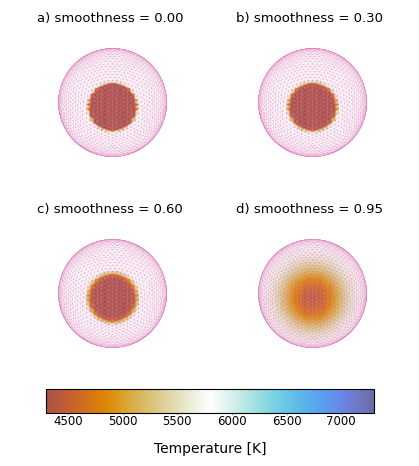

In [5]:
ROW_SPACING = 0.0
HEIGHT_PER_ROW = 2
CBAR_HEIGHT_RATIO = 0.1

CMAP = 'cmr.prinsenvlag'
VIEW = dict(elev=15, azim=0)
# Symmetric diverging norm around T_BASE so the cmap midpoint always sits
# on the photosphere even when (as here) the spot is purely cool, which
# would otherwise collapse vmax to T_BASE and break TwoSlopeNorm.
norm = mpl.colors.TwoSlopeNorm(
    vcenter=T_BASE,
    vmin=T_BASE - T_DELTA,
    vmax=T_BASE + T_DELTA,
)
cmap = mpl.colormaps[CMAP]

def strip_axes(ax):
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor('none')
    ax.grid(False)
    ax.set_axis_off()
    ax.set_facecolor('none')

def draw_mesh(ax, mesh):
    poly = art3d.Poly3DCollection(
        np.asarray(mesh.mesh_elements),
        facecolors=cmap(norm(np.asarray(mesh.parameters[:, 0]))),
        edgecolor='mediumvioletred', linewidths=0.05)
    poly.set_rasterized(True)
    ax.add_collection(poly)
    lim = 1.05 * float(mesh.radius)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), zlim=(-lim, lim))
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(**VIEW)

n_cols = 2
n_rows = -(-len(configurations) // n_cols)

fig = plt.figure(figsize=(2 * n_cols, HEIGHT_PER_ROW * n_rows + 0.01))
gs = fig.add_gridspec(
    n_rows + 1, n_cols,
    height_ratios=[1] * n_rows + [CBAR_HEIGHT_RATIO],
    wspace=0, hspace=ROW_SPACING)

for i, (cfg, mesh) in enumerate(zip(configurations, spotted_meshes)):
    r, c = divmod(i, n_cols)
    ax = fig.add_subplot(gs[r, c], projection='3d')
    strip_axes(ax)
    draw_mesh(ax, mesh)
    ax.set_title(cfg['title'], fontsize=9.5, pad=0.01, y=1.02)

cax = fig.add_subplot(gs[-1, :])
cax.axis('off')

# (x, y, width, height) in cax-axes coords; matches spots_configurations layout.
inset_ax = cax.inset_axes([0.5 - 0.82 / 2, -0.125, 0.82, 1.25])

cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
    cax=inset_ax,
    orientation='horizontal',
)
cbar.set_label('Temperature [K]', fontsize=10, labelpad=10)
cbar.ax.tick_params(length=1, labelsize=8.5, pad=0.5)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig.savefig('spot_smoothness.pdf', bbox_inches='tight', dpi=300)
plt.show()